In [ ]:
import sys
import os

print(sys.executable)
print(os.getcwd())

D:\Github_Ku\bda-recsys-project\Recsys\python.exe
D:\Github_Ku\bda-recsys-project\notebooks\external


***

This script performs:
1. Data preprocessing (cleaning + K-core filtering)
2. ID remapping
3. Sequence construction (for Transformer models)
4. Graph construction (User-Item + Item-Item)
5. Negative sampling (popularity-based)
6. PyTorch Dataset preparation
***

In [3]:
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from tqdm import tqdm

In [5]:
# ==============================
# 1. Load Data
# ==============================

# Load dataset
df = pd.read_csv("D:/Github_Ku/bda-recsys-project/data/raw/ratings_Electronics.csv", header=None)
df.columns = ['userId', 'itemId', 'rating', 'timestamp']

print("Raw data size:", df.shape)

Raw data size: (1048576, 4)


In [6]:
# ==============================
# 2. Convert to Implicit Feedback
# ==============================

# Keep only positive interactions (rating >= 3)
df = df[df['rating'] >= 3]

print("After implicit filtering:", df.shape)
df.head()

After implicit filtering: (857681, 4)


,userId,itemId,rating,timestamp
0,AKM1MP6P0OYPR,132793040,5,1365811200
1,A2CX7LUOHB2NDG,321732944,5,1341100800
3,A2WNBOD3WNDNKT,439886341,3,1374451200
5,A1QGNMC6O1VW39,511189877,5,1397433600
7,A2TY0BTJOTENPG,511189877,5,1395878400


In [7]:
# ==============================
# 3. K-Core Filtering
# ==============================

def k_core_filter(df, k=5):
    """
    Iteratively remove users and items with interactions < k
    """
    while True:
        user_counts = df['userId'].value_counts()
        item_counts = df['itemId'].value_counts()

        df = df[
            df['userId'].isin(user_counts[user_counts >= k].index) &
            df['itemId'].isin(item_counts[item_counts >= k].index)
        ]

        # Stop condition
        if (user_counts < k).sum() == 0 and (item_counts < k).sum() == 0:
            break

    return df


df = k_core_filter(df, k=5)

print("After K-core filtering:", df.shape)
df.head()

After K-core filtering: (20402, 4)


,userId,itemId,rating,timestamp
389,A6J8D9V5S9MBE,972683275,5,1306886400
631,A3TAS1AG6FMBQW,972683275,5,1353456000
636,A2T4OX8NH9LIIC,972683275,5,1358553600
1003,A2Y4H3PXB07WQI,972683275,4,1292457600
1045,ABU4LUKJU2QOY,972683275,5,1378339200


In [8]:
# ==============================
# 4. ID Remapping
# ==============================

# user id can start from 0
user2id = {u: idx for idx, u in enumerate(df["userId"].unique())}

# item id must start from 1
# 0 is reserved for padding
item2id = {item: idx + 1 for idx, item in enumerate(df["itemId"].unique())}

df["userId"] = df["userId"].map(user2id)
df["itemId"] = df["itemId"].map(item2id)

num_users = len(user2id)
num_items = len(item2id)
padding_idx = 0

print("Number of users:", num_users)
print("Number of items:", num_items)
print("Padding idx:", padding_idx)
print("Min item id:", df["itemId"].min())
print("Max item id:", df["itemId"].max())

df.head()

Number of users: 2856
Number of items: 1706
Padding idx: 0
Min item id: 1
Max item id: 1706


,userId,itemId,rating,timestamp
389,0,1,5,1306886400
631,1,1,5,1353456000
636,2,1,5,1358553600
1003,3,1,4,1292457600
1045,4,1,5,1378339200


In [9]:
    # ==============================
    # 5. Sort by Time (Sequence Modeling)
    # ==============================

    df = df.sort_values(['userId', 'timestamp'])

    # Build user sequences
    user_seq = df.groupby('userId')['itemId'].apply(list)

    print("Example user sequence:", user_seq.iloc[0])

Example user sequence: [230, 1671, 1038, 220, 1101, 1436, 472, 1250, 1441, 1, 1670]


In [10]:
# ==============================
# 6. Build Graphs (FULL DATA)
# ==============================

# ---- User-Item Graph ----
user_nodes = df['userId'].values
item_nodes = df['itemId'].values + num_users

edge_index_ui = torch.tensor([
    list(user_nodes) + list(item_nodes),
    list(item_nodes) + list(user_nodes)
], dtype=torch.long)


# ---- Item-Item Graph ----
def build_item_graph(user_seq, window=3):
    cooc = defaultdict(int)

    for seq in tqdm(user_seq):
        for i in range(len(seq)):
            for j in range(i+1, min(i+window, len(seq))):
                cooc[(seq[i], seq[j])] += 1
                cooc[(seq[j], seq[i])] += 1

    edges = list(cooc.keys())
    return torch.tensor(edges, dtype=torch.long).t()


edge_index_ii = build_item_graph(user_seq)

print("User-Item graph edges:", edge_index_ui.shape)
print("Item-Item graph edges:", edge_index_ii.shape)



100%|██████████| 2856/2856 [00:00<00:00, 31260.10it/s]

User-Item graph edges: torch.Size([2, 40804])
Item-Item graph edges: torch.Size([2, 56952])


In [11]:
# ==============================
# 7. Time-based Split
# ==============================

train_data, val_data, test_data = [], [], []

for u, seq in user_seq.items():
    if len(seq) < 3:
        continue

    train_seq = seq[:-2]
    val_item = seq[-2]
    test_item = seq[-1]

    train_data.append((u, train_seq))
    val_data.append((u, train_seq, val_item))
    test_data.append((u, train_seq + [val_item], test_item))


print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print("Test samples:", len(test_data))


Train samples: 2856
Val samples: 2856
Test samples: 2856


In [12]:
import os
import torch

export_dir = r"D:\Github_Ku\bda-recsys-project\data\interim"
os.makedirs(export_dir, exist_ok=True)

print("Export dir:", export_dir)
print("Exists:", os.path.exists(export_dir))

Export dir: D:\Github_Ku\bda-recsys-project\data\interim
Exists: True


In [13]:
clean_user_sequences = {}

df_sorted = df.sort_values(["userId", "timestamp"]).copy()

for user_id, user_df in df_sorted.groupby("userId"):
    clean_user_sequences[int(user_id)] = {
        "items": user_df["itemId"].tolist(),
        "times": user_df["timestamp"].tolist(),
    }

print("number of users in clean_user_sequences:", len(clean_user_sequences))

first_user = next(iter(clean_user_sequences))
print("first user:", first_user)
print(clean_user_sequences[first_user])

torch.save(clean_user_sequences, os.path.join(export_dir, "clean_user_sequences.pt"))
print("Saved clean_user_sequences.pt")

number of users in clean_user_sequences: 2856
first user: 0
{'items': [230, 1671, 1038, 220, 1101, 1436, 472, 1250, 1441, 1, 1670], 'times': [1162252800, 1171756800, 1192147200, 1192752000, 1201392000, 1223251200, 1232236800, 1232236800, 1232236800, 1306886400, 1308096000]}
Saved clean_user_sequences.pt


In [14]:
artifacts = {
    "train_data": train_data,
    "val_data": val_data,
    "test_data": test_data,
    "user2id": user2id,
    "item2id": item2id,
    "num_users": num_users,
    "num_items": num_items,
    "padding_idx": 0,
}

torch.save(artifacts, os.path.join(export_dir, "sequence_artifacts.pt"))
print("Saved sequence_artifacts.pt")

Saved sequence_artifacts.pt


In [15]:
torch.save(edge_index_ui, os.path.join(export_dir, "edge_index_ui.pt"))
torch.save(edge_index_ii, os.path.join(export_dir, "edge_index_ii.pt"))

print("Saved edge_index_ui.pt")
print("Saved edge_index_ii.pt")

Saved edge_index_ui.pt
Saved edge_index_ii.pt


In [13]:
# ==============================
# 8. Popularity-based Negative Sampling
# ==============================

train_items = []

for _, seq in train_data:
    train_items.extend(seq)

item_popularity = pd.Series(train_items).value_counts().to_dict()

items = list(item_popularity.keys())
weights = [item_popularity[i] for i in items]

def negative_sample(user_history, num_samples=100):
    """
    Popularity-based negative sampling
    Avoid sampling items already interacted by user
    """
    negs = set()

    while len(negs) < num_samples:
        sampled = random.choices(items, weights=weights, k=1)[0]

        if sampled not in user_history:
            negs.add(sampled)

    return list(negs)

In [14]:
# ==============================
# 9. Dataset (Transformer-ready)
# ==============================

class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len=50, neg_size=1):
        self.data = data
        self.max_len = max_len
        self.neg_size = neg_size

    def pad(self, seq):
        seq = seq[-self.max_len:]
        return [0]*(self.max_len - len(seq)) + seq

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        u, seq = self.data[idx]

        input_seq = self.pad(seq[:-1])
        pos_item = seq[-1]

        # negative sampling
        neg_items = negative_sample(seq, self.neg_size)

        return (
            torch.tensor(input_seq),
            torch.tensor(pos_item),
            torch.tensor(neg_items)
        )
    
class EvalTestDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len=50):
        self.data = data
        self.max_len = max_len

    def pad(self, seq):
        seq = seq[-self.max_len:]
        return [0]*(self.max_len - len(seq)) + seq

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        u, seq, target = self.data[idx]

        input_seq = self.pad(seq)

        return torch.tensor(input_seq), torch.tensor(target)
    
train_dataset = TrainDataset(train_data)
val_dataset = EvalTestDataset(val_data)
test_dataset = EvalTestDataset(test_data)

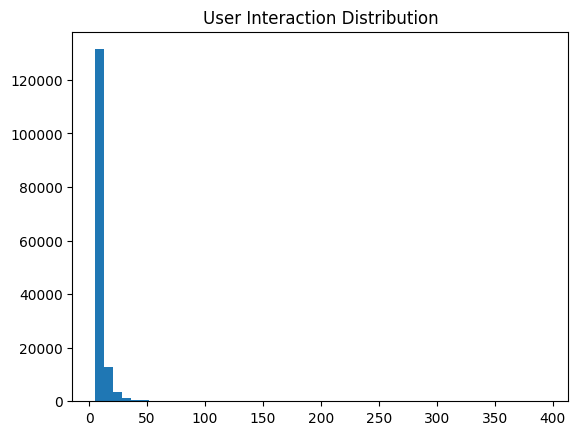

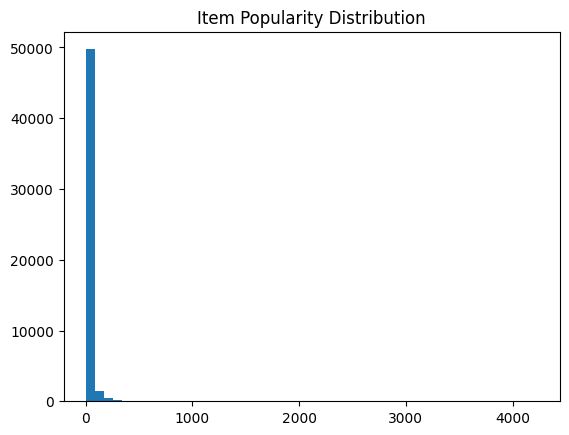

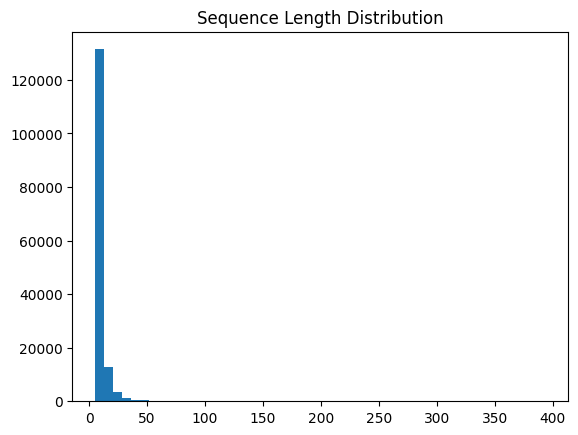

In [15]:
    # ==============================
    # 10. Data Visualization
    # ==============================

    # User distribution
    plt.figure()
    plt.hist(df['userId'].value_counts(), bins=50)
    plt.title("User Interaction Distribution")
    plt.show()

    # Item distribution
    plt.figure()
    plt.hist(df['itemId'].value_counts(), bins=50)
    plt.title("Item Popularity Distribution")
    plt.show()

    # Sequence length
    plt.figure()
    plt.hist(user_seq.apply(len), bins=50)
    plt.title("Sequence Length Distribution")
    plt.show()


In [16]:
# ==============================
# 11. Sparsity
# ==============================

sparsity = 1 - len(df)/(num_users*num_items)
print("Sparsity:", sparsity)

Sparsity: 0.999832399955512


In [17]:
# ==============================
# 12. Save
# ==============================

torch.save(edge_index_ui, "edge_index_ui.pt")
torch.save(edge_index_ii, "edge_index_ii.pt")

In [18]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GraphTransformerRec(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_heads=4, num_layers=2, max_len=50):
        super(GraphTransformerRec, self).__init__()
        
        self.embedding_dim = embedding_dim
        
        # 1. Embeddings
        # 物品ID从0开始，0通常留给Padding，所以这里num_items+1
        self.item_emb = nn.Embedding(num_items + 1, embedding_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embedding_dim)
        
        # 2. Graph Branch (GCN) - 学习全局物品表示
        self.gcn1 = GCNConv(embedding_dim, embedding_dim)
        self.gcn2 = GCNConv(embedding_dim, embedding_dim)
        
        # 3. Sequence Branch (Transformer) - 学习用户行为模式
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, 
            nhead=num_heads, 
            dim_feedforward=embedding_dim*4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, seq, edge_index_ii):
        # A. 图特征提取
        # 获取所有物品的初始embedding
        all_item_ids = torch.arange(self.item_emb.num_embeddings).to(seq.device)
        x = self.item_emb(all_item_ids)
        
        # 两层GCN：增强物品的结构信息
        x_g = F.relu(self.gcn1(x, edge_index_ii))
        x_g = self.gcn2(x_g, edge_index_ii) 
        
        # B. 序列特征提取
        # 获取序列中物品经过GCN增强后的embedding
        seq_emb = x_g[seq] # [batch, max_len, dim]
        
        # 加上位置编码
        batch_size, seq_len = seq.size()
        pos = torch.arange(seq_len).unsqueeze(0).to(seq.device)
        pos_emb = self.pos_emb(pos)
        
        seq_features = self.dropout(seq_emb + pos_emb)
        
        # Transformer 处理 (需要考虑Padding mask)
        mask = (seq == 0) # 假设0是padding
        out = self.transformer(seq_features, src_key_padding_mask=mask)
        
        # 取最后一个时间步作为用户表示
        user_repr = out[:, -1, :] 
        
        return user_repr, x_g # 返回用户表示和全局物品表示

C:\Users\Ryan\miniconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
def bpr_loss(user_emb, pos_item_emb, neg_item_emb):
    pos_score = torch.sum(user_emb * pos_item_emb, dim=-1)
    neg_score = torch.sum(user_emb * neg_item_emb, dim=-1)
    loss = -torch.mean(F.logsigmoid(pos_score - neg_score))
    return loss

def train_one_epoch(model, loader, optimizer, edge_index, device):
    model.train()
    total_loss = 0
    for seq, pos_item, neg_item in loader:
        seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
        
        optimizer.zero_grad()
        user_repr, item_embs = model(seq, edge_index)
        
        # 提取正负样本的 embedding
        pos_emb = item_embs[pos_item]
        neg_emb = item_embs[neg_item].squeeze(1) # [batch, dim]
        
        loss = bpr_loss(user_repr, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

In [20]:
@torch.no_grad()
def evaluate(model, loader, edge_index, device, k=10):
    model.eval()
    hr, ndcg = [], []
    
    # 预先计算所有物品的表示以加速
    _, all_item_embs = model(torch.zeros((1, 50), dtype=torch.long).to(device), edge_index)
    
    for seq, target in loader:
        seq, target = seq.to(device), target.to(device)
        user_repr, _ = model(seq, edge_index)
        
        # 计算该用户对所有物品的得分
        scores = torch.matmul(user_repr, all_item_embs.t()) # [batch, num_items]
        
        # 获取 Top-K
        _, top_k_idx = torch.topk(scores, k, dim=-1)
        
        for i in range(len(target)):
            gt = target[i].item()
            recs = top_k_idx[i].cpu().numpy()
            
            # Hit Rate
            if gt in recs:
                hr.append(1)
                # NDCG
                rank = list(recs).index(gt)
                ndcg.append(1 / np.log2(rank + 2))
            else:
                hr.append(0)
                ndcg.append(0)
                
    return np.mean(hr), np.mean(ndcg)

Using device: cuda


  Training:  11%|█████▌                                            | 65/588 [00:51<06:54,  1.26it/s, batch_loss=0.6793]


  Training:  22%|██████████▉                                      | 131/588 [01:42<05:55,  1.28it/s, batch_loss=0.6773]


  Training:  34%|████████████████▍                                | 197/588 [02:34<05:22,  1.21it/s, batch_loss=0.6210]


  Training:  45%|█████████████████████▉                           | 263/588 [03:27<04:17,  1.26it/s, batch_loss=0.6303]


...

  Evaluating:  46%|██████████████████████████████▌                                   | 272/588 [00:36<00:42,  7.38it/s]


  Evaluating:  69%|█████████████████████████████████████████████▎                    | 404/588 [00:53<00:22,  8.32it/s]


  Evaluating:  91%|████████████████████████████████████████████████████████████▏     | 536/588 [01:09<00:06,  8.43it/s]


Total Progress: 100%|███████████████████████████████████████████████████████████████████| 1/1 [09:01<00:00, 541.71s/it]


Epoch 01 | Loss: 0.6310 | HR@10: 0.0123 | NDCG@10: 0.0062


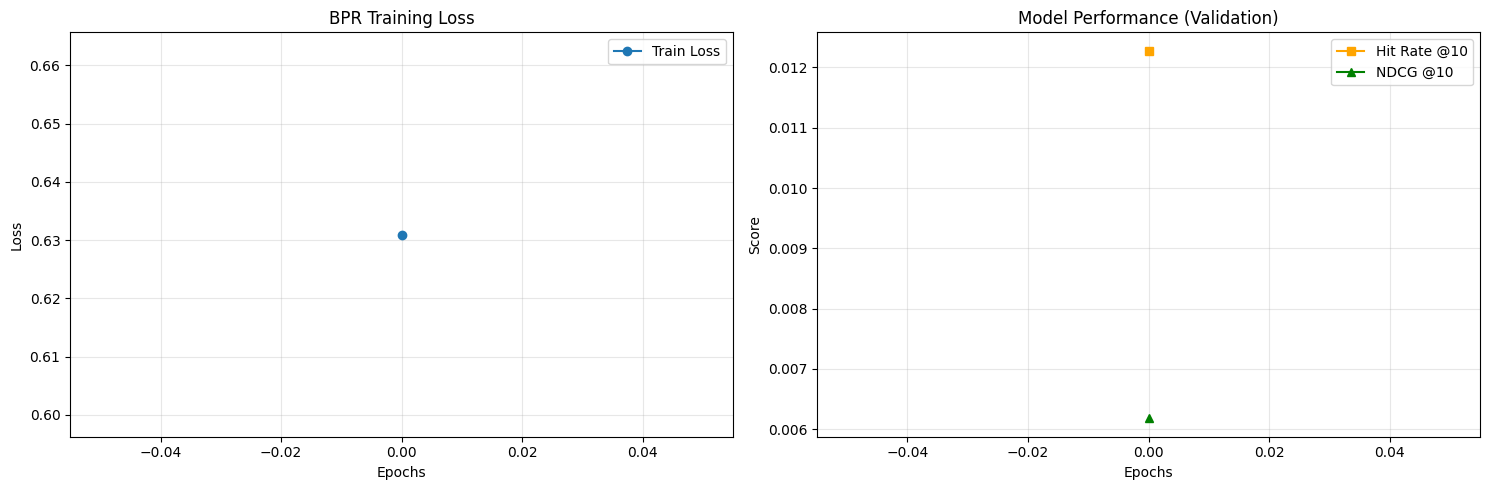

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 12. 模型定义 (包含 Robust Mask 修复)
# ==============================
class GraphTransformerRec(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_heads=4, num_layers=2, max_len=50):
        super(GraphTransformerRec, self).__init__()
        
        self.embedding_dim = embedding_dim
        # 物品ID映射，0用于Padding，实际物品从1开始（或映射后偏移）
        self.item_emb = nn.Embedding(num_items + 1, embedding_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embedding_dim)
        
        # GCN 部分
        self.gcn1 = GCNConv(embedding_dim, embedding_dim)
        self.gcn2 = GCNConv(embedding_dim, embedding_dim)
        
        # Transformer 部分
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, 
            nhead=num_heads, 
            dim_feedforward=embedding_dim*4,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(0.1)

    def forward(self, seq, edge_index_ii):
        # 1. 全局图特征提取
        all_item_ids = torch.arange(self.item_emb.num_embeddings).to(seq.device)
        x = self.item_emb(all_item_ids)
        x_g = F.relu(self.gcn1(x, edge_index_ii))
        x_g = self.gcn2(x_g, edge_index_ii) 
        
        # 2. 序列特征提取
        seq_emb = x_g[seq] 
        
        batch_size, seq_len = seq.size()
        pos = torch.arange(seq_len).unsqueeze(0).to(seq.device)
        pos_emb = self.pos_emb(pos)
        
        seq_features = self.dropout(seq_emb + pos_emb)
        
        # 3. 健壮的 Transformer Mask 处理
        mask = (seq == 0)
        # 核心修复：如果整行都是True(全Padding)，强行把第一位设为False，防止Transformer崩溃
        if mask.any():
            full_padding_rows = mask.all(dim=-1)
            mask[full_padding_rows, 0] = False

        out = self.transformer(seq_features, src_key_padding_mask=mask)
        
        # 取最后一个有效步作为用户表示
        user_repr = out[:, -1, :] 
        
        return user_repr, x_g

# ==============================
# 13. 损失函数与评估逻辑
# ==============================
def bpr_loss(user_emb, pos_item_emb, neg_item_emb):
    pos_score = torch.sum(user_emb * pos_item_emb, dim=-1)
    neg_score = torch.sum(user_emb * neg_item_emb, dim=-1)
    return -torch.mean(F.logsigmoid(pos_score - neg_score))

@torch.no_grad()
def evaluate(model, loader, edge_index, device, k=10):
    model.eval()
    hr, ndcg = [], []
    
    # 预先计算所有物品表示（此时传入一个非全0的dummy seq）
    dummy_seq = torch.ones((1, 50), dtype=torch.long).to(device)
    _, all_item_embs = model(dummy_seq, edge_index)
    
    for seq, target in tqdm(loader, desc="  Evaluating", leave=False):
        seq, target = seq.to(device), target.to(device)
        user_repr, _ = model(seq, edge_index)
        
        # 计算得分并排序
        scores = torch.matmul(user_repr, all_item_embs.t())
        _, top_k_idx = torch.topk(scores, k, dim=-1)
        
        for i in range(len(target)):
            gt = target[i].item()
            recs = top_k_idx[i].cpu().numpy()
            if gt in recs:
                hr.append(1)
                rank = list(recs).index(gt)
                ndcg.append(1 / np.log2(rank + 2))
            else:
                hr.append(0)
                ndcg.append(0)
                
    return np.mean(hr), np.mean(ndcg)

def train_one_epoch(model, loader, optimizer, edge_index, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="  Training", leave=False)
    
    for seq, pos_item, neg_item in pbar:
        seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
        
        optimizer.zero_grad()
        user_repr, item_embs = model(seq, edge_index)
        
        pos_emb = item_embs[pos_item]
        neg_emb = item_embs[neg_item].squeeze(1)
        
        loss = bpr_loss(user_repr, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
        
    return total_loss / len(loader)

# ==============================
# 14. 主运行流程
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 数据加载
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=256)

# 初始化模型
model = GraphTransformerRec(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
edge_index_ii = edge_index_ii.to(device)

history = {'loss': [], 'hr': [], 'ndcg': []}

# 训练循环
epochs = 10
epoch_pbar = tqdm(range(1, epochs + 1), desc="Total Progress")

for epoch in epoch_pbar:
    train_loss = train_one_epoch(model, train_loader, optimizer, edge_index_ii, device)
    val_hr, val_ndcg = evaluate(model, val_loader, edge_index_ii, device)
    
    history['loss'].append(train_loss)
    history['hr'].append(val_hr)
    history['ndcg'].append(val_ndcg)
    
    print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | HR@10: {val_hr:.4f} | NDCG@10: {val_ndcg:.4f}")

# ==============================
# 15. 结果可视化
# ==============================
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], marker='o', label='Train Loss')
plt.title('BPR Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['hr'], marker='s', label='Hit Rate @10', color='orange')
plt.plot(history['ndcg'], marker='^', label='NDCG @10', color='green')
plt.title('Model Performance (Validation)')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

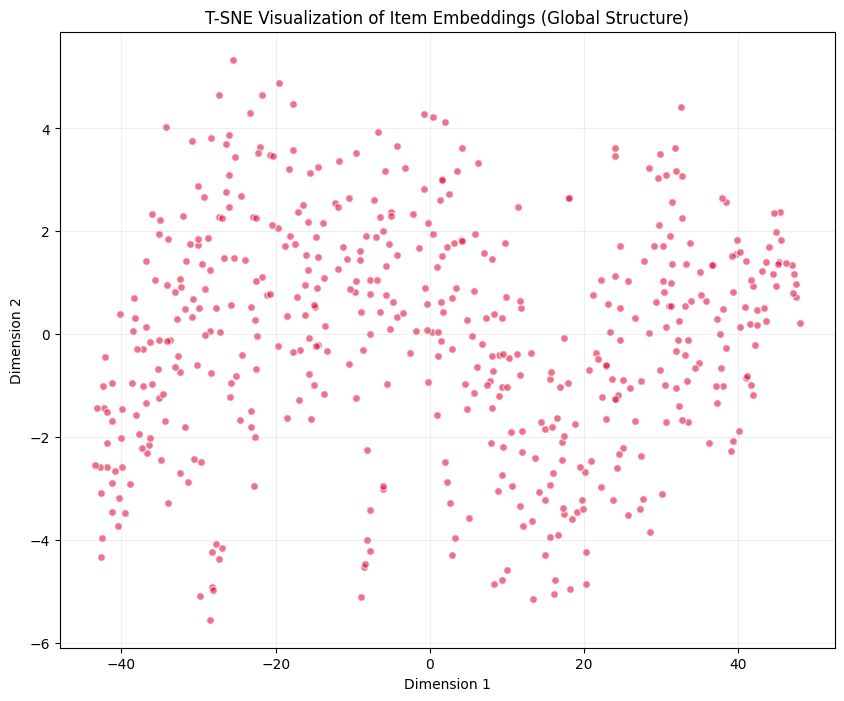

In [23]:
from sklearn.manifold import TSNE

def plot_item_embeddings(model, edge_index, num_items_to_plot=500):
    model.eval()
    with torch.no_grad():
        # 获取经过GCN增强后的物品Embedding
        _, item_embs = model(torch.ones((1, 50), dtype=torch.long).to(device), edge_index)
        # 取前N个热门物品（避开长尾噪声）
        embeddings = item_embs[1:num_items_to_plot+1].cpu().numpy()
        
    tsne = TSNE(n_components=2, random_state=42)
    low_dim_embs = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(low_dim_embs[:, 0], low_dim_embs[:, 1], alpha=0.6, c='crimson', edgecolors='w', s=30)
    plt.title('T-SNE Visualization of Item Embeddings (Global Structure)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.2)
    plt.show()

plot_item_embeddings(model, edge_index_ii)

In [ ]:
def plot_score_distribution(model, loader, edge_index, device):
    model.eval()
    pos_scores = []
    neg_scores = []
    
    with torch.no_grad():
        for seq, pos_item, neg_item in loader:
            seq, pos_item, neg_item = seq.to(device), pos_item.to(device), neg_item.to(device)
            user_repr, item_embs = model(seq, edge_index)
            
            p_score = torch.sum(user_repr * item_embs[pos_item], dim=-1)
            n_score = torch.sum(user_repr * item_embs[neg_item].squeeze(1), dim=-1)
            
            pos_scores.extend(p_score.cpu().numpy())
            neg_scores.extend(n_score.cpu().numpy())

    plt.figure(figsize=(10, 6))
    plt.hist(pos_scores, bins=50, alpha=0.5, label='Positive Items', color='g', density=True)
    plt.hist(neg_scores, bins=50, alpha=0.5, label='Negative Items', color='r', density=True)
    plt.title('Score Distribution: Positive vs Negative Samples')
    plt.xlabel('Prediction Score')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# 使用训练集的一小部分查看
plot_score_distribution(model, train_loader, edge_index_ii, device)

In [ ]:
def plot_performance_by_length(model, dataset, edge_index, device):
    lengths = [torch.count_nonzero(seq).item() for seq, _ in dataset]
    results = [] # 存储 (length, hit)
    
    model.eval()
    with torch.no_grad():
        # 预计算所有物品表示
        dummy_seq = torch.ones((1, 50), dtype=torch.long).to(device)
        _, all_item_embs = model(dummy_seq, edge_index)
        
        for seq, target in dataset:
            seq_len = torch.count_nonzero(seq).item()
            seq_tensor = seq.unsqueeze(0).to(device)
            user_repr, _ = model(seq_tensor, edge_index)
            
            scores = torch.matmul(user_repr, all_item_embs.t())
            _, top_k = torch.topk(scores, 10)
            hit = 1 if target.item() in top_k[0].cpu().numpy() else 0
            results.append((seq_len, hit))

    df_res = pd.DataFrame(results, columns=['length', 'hit'])
    # 按长度分组计算平均HR
    len_acc = df_res.groupby('length')['hit'].mean()

    plt.figure(figsize=(10, 5))
    len_acc.plot(kind='bar', color='skyblue')
    plt.title('HitRate@10 vs. User Sequence Length')
    plt.xlabel('Sequence Length')
    plt.ylabel('Average HitRate')
    plt.xticks(rotation=0)
    plt.show()

# 示例调用
plot_performance_by_length(model, val_dataset, edge_index_ii, device)

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch_geometric.nn import GCNConv, LGConv
from tqdm import tqdm
import random
from collections import defaultdict

# ==============================
# 1. 修复后的预处理逻辑
# ==============================
def preprocess_data(file_path, k=5, min_rating=3):
    print(f">>> Filtering data (k={k}, min_rating={min_rating})...")
    df = pd.read_csv(file_path, header=None, names=['userId', 'itemId', 'rating', 'timestamp'])
    df = df[df['rating'] >= min_rating]

    prev_len = -1
    while len(df) != prev_len:
        prev_len = len(df)
        u_counts = df['userId'].value_counts()
        df = df[df['userId'].isin(u_counts[u_counts >= k].index)]
        i_counts = df['itemId'].value_counts()
        df = df[df['itemId'].isin(i_counts[i_counts >= k].index)]

        print(f">>> Filtering progress: rows={len(df)}, users={df['userId'].nunique()}, items={df['itemId'].nunique()}")
        if len(df) == 0:
            break

    if len(df) == 0:
        raise ValueError('Filtered data is empty. Try smaller k or lower min_rating.')

    user2id = {u: i for i, u in enumerate(df['userId'].unique())}
    item2id = {item: i + 1 for i, item in enumerate(df['itemId'].unique())}
    df['userId'] = df['userId'].map(user2id)
    df['itemId'] = df['itemId'].map(item2id)

    num_users, num_items = len(user2id), len(item2id)
    print(f">>> Remaining after filtering: users={num_users}, items={num_items}")

    df = df.sort_values(['userId', 'timestamp'])
    user_seq = df.groupby('userId')['itemId'].apply(list).to_dict()

    print('>>> Building global graph...')
    cooc = defaultdict(int)
    for seq in user_seq.values():
        for i in range(len(seq)):
            for j in range(i + 1, min(i + 3, len(seq))):
                cooc[(seq[i], seq[j])] += 1
                cooc[(seq[j], seq[i])] += 1
    edge_ii = torch.tensor(list(cooc.keys()), dtype=torch.long).t()

    u_nodes, i_nodes = df['userId'].values, df['itemId'].values + num_users
    edge_ui = torch.from_numpy(
        np.stack([
            np.concatenate([u_nodes, i_nodes]),
            np.concatenate([i_nodes, u_nodes]),
        ])
    ).long()

    train_samples, test_samples = [], []
    all_items = list(item2id.values())
    sample_size = min(len(all_items), 101)

    for _, seq in user_seq.items():
        if len(seq) < 5:
            continue
        for i in range(2, len(seq) - 1):
            train_samples.append((seq[:i], seq[i]))

        target = seq[-1]
        negs = random.sample(all_items, sample_size)
        if target in negs:
            negs.remove(target)
        test_samples.append((seq[:-1], target, negs[:99]))

    print(f">>> train_samples={len(train_samples)}, test_samples={len(test_samples)}")
    if len(train_samples) == 0:
        raise ValueError('train_samples is empty after filtering. Decrease k or min_rating.')

    return train_samples, test_samples, edge_ii, edge_ui, num_users, num_items

# ==============================
# 2. 模型库 (保持 InfoNCE 架构)
# ==============================
class BaseRecommender(nn.Module):
    def __init__(self, num_items, dim=128):
        super().__init__()
        self.item_emb = nn.Embedding(num_items + 2, dim, padding_idx=0)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        self.tau = 0.15 

    def get_repr(self, user_repr, item_pool):
        return F.normalize(user_repr, p=2, dim=-1), F.normalize(item_pool, p=2, dim=-1)

class GRU4Rec(BaseRecommender):
    def __init__(self, num_items, dim=128):
        super().__init__(num_items, dim)
        self.gru = nn.GRU(dim, dim, batch_first=True, num_layers=2)
    def forward(self, seq, *args):
        _, hn = self.gru(self.item_emb(seq))
        return self.get_repr(hn[-1], self.item_emb.weight)

class SASRec(BaseRecommender):
    def __init__(self, num_items, dim=128, max_len=50):
        super().__init__(num_items, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=dim, nhead=8, batch_first=True), num_layers=2)
    def forward(self, seq, *args):
        x = self.item_emb(seq) + self.pos_emb(torch.arange(seq.size(1)).to(seq.device))
        user_repr = self.transformer(x, src_key_padding_mask=(seq==0))[:, -1, :]
        return self.get_repr(user_repr, self.item_emb.weight)

class LightGCN(BaseRecommender):
    def __init__(self, num_users, num_items, dim=128):
        super().__init__(num_items, dim)
        self.u_emb = nn.Embedding(num_users, dim)
        self.conv = LGConv()
        self.num_users = num_users
    def forward(self, seq, edge_index):
        x = self.conv(torch.cat([self.u_emb.weight, self.item_emb.weight]), edge_index)
        i_final = x[self.num_users:]
        user_repr = i_final[seq[:, -1]]
        return self.get_repr(user_repr, i_final)

class GSTTransformer(BaseRecommender):
    def __init__(self, num_items, dim=128, max_len=50):
        super().__init__(num_items, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.gcn = GCNConv(dim, dim)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=dim, nhead=8, batch_first=True), num_layers=2)
    def forward(self, seq, edge_ii):
        g_items = self.gcn(self.item_emb.weight, edge_ii)
        x = g_items[seq] + self.pos_emb(torch.arange(seq.size(1)).to(seq.device))
        user_repr = self.transformer(x, src_key_padding_mask=(seq==0))[:, -1, :]
        return self.get_repr(user_repr, g_items)

# ==============================
# 3. 运行引擎
# ==============================
def run_experiment(name, model, train_loader, test_data, edge, device):
    print(f"\n>>> 运行实验: {name}")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(5): # 降低 Epoch 演示，实际上 10 轮更好
        model.train()
        for seq, pos in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
            seq, pos = seq.to(device), pos.to(device)
            optimizer.zero_grad()
            u_v, i_v = model(seq, edge)
            logits = torch.matmul(u_v, i_v.t()) / model.tau
            loss = F.cross_entropy(logits, pos)
            loss.backward(); optimizer.step()
            
        hr = evaluate(model, test_data, edge, device)
        print(f"Epoch {epoch} | HR@10: {hr:.4f}")
    return hr

@torch.no_grad()
def evaluate(model, test_data, edge, device):
    model.eval()
    hr_count = 0
    for seq, pos, negs in test_data:
        seq_tensor = torch.tensor([([0]*50 + seq)[-50:]]).to(device)
        u_v, i_v = model(seq_tensor, edge)
        candidates = torch.tensor([pos] + negs).to(device)
        scores = torch.matmul(u_v, i_v[candidates].t())
        if 0 in torch.topk(scores, 10)[1]: hr_count += 1
    return hr_count / len(test_data)

class SeqDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        seq, pos = self.data[idx]
        return torch.tensor(([0]*50 + seq)[-50:]), torch.tensor(pos)

# ==============================
# 4. 执行
# ==============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    FILE_PATH = "D:/Github_Ku/bda-recsys-project/data/raw/ratings_Electronics.csv"
    
    train_data, test_data, edge_ii, edge_ui, n_u, n_i = preprocess_data(FILE_PATH, k=5, min_rating=3)
    print(f"Prepared train/test samples: {len(train_data)}/{len(test_data)}")
    if len(train_data) == 0:
        raise ValueError("train_data is empty after preprocess; reduce k or min_rating")
    train_loader = DataLoader(SeqDataset(train_data), batch_size=256, shuffle=True)
    
    edge_ii, edge_ui = edge_ii.to(device), edge_ui.to(device)

    results = {}
    results['GRU4Rec'] = run_experiment('GRU4Rec', GRU4Rec(n_i), train_loader, test_data, edge_ii, device)
    results['SASRec'] = run_experiment('SASRec', SASRec(n_i), train_loader, test_data, edge_ii, device)
    results['LightGCN'] = run_experiment('LightGCN', LightGCN(n_u, n_i), train_loader, test_data, edge_ui, device)
    results['GST-Trans'] = run_experiment('GST-Trans', GSTTransformer(n_i), train_loader, test_data, edge_ii, device)

    print("\n--- Final Results ---")
    for k, v in results.items(): print(f"{k}: {v:.4f}")





>>> 正在过滤数据 (K=10)...


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Big_Data_Analytics/final_project/ratings_Electronics.csv/ratings_Electronics.csv'

>>> 正在读取并过滤数据 (K=10)...

>>> Running: GRU4Rec


[*] GRU4Rec Final HR@10: 0.5220


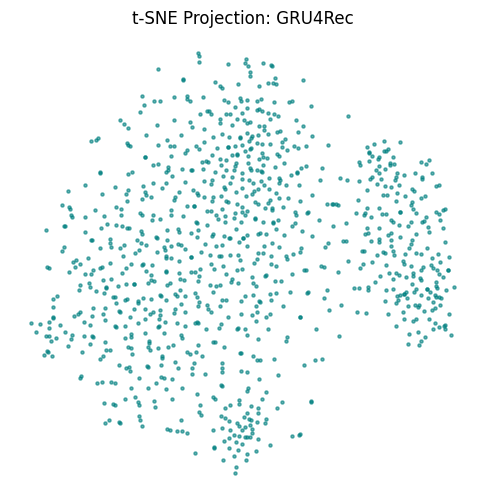


>>> Running: SASRec


[*] SASRec Final HR@10: 0.4780


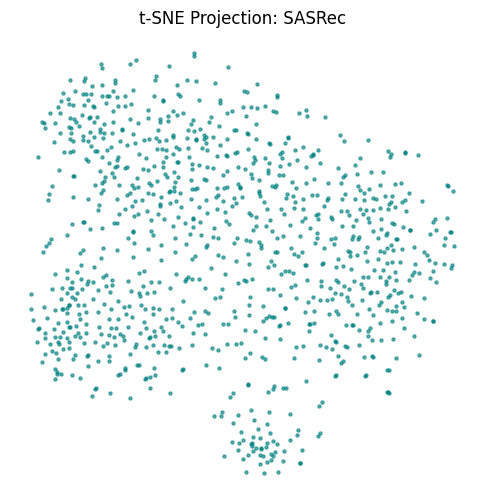


>>> Running: GST-Trans


[*] GST-Trans Final HR@10: 0.5440


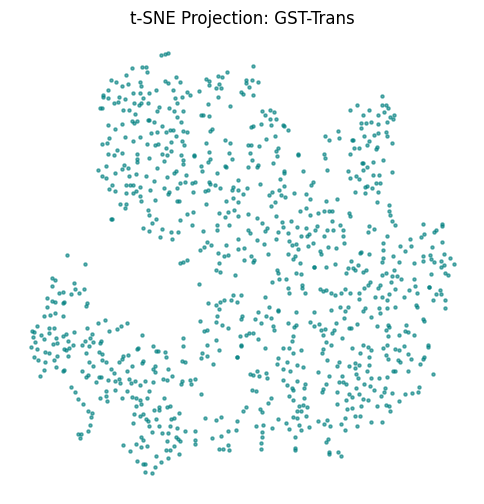

C:\Users\Ryan\AppData\Local\Temp\ipykernel_54812\1508491967.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, ax=axes[0], palette="magma")


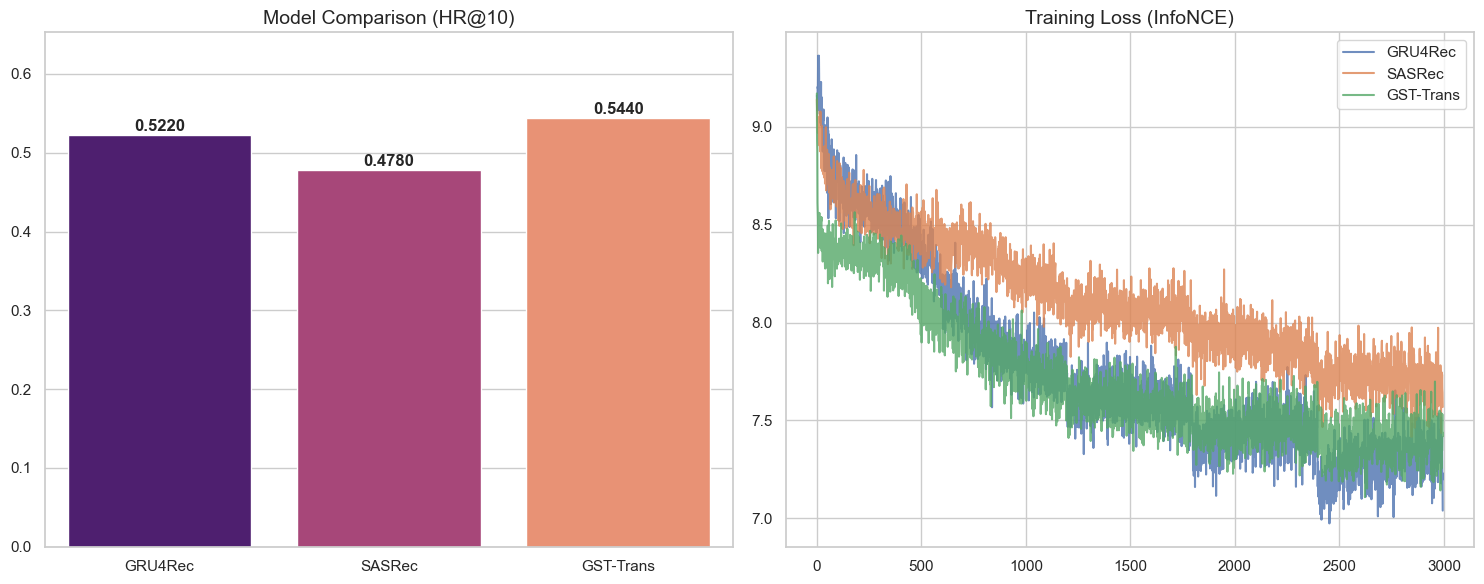

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch_geometric.nn import GCNConv, LGConv
from tqdm import tqdm
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==============================
# 1. 鲁棒的数据预处理逻辑
# ==============================
def preprocess_data(file_path, k=5, min_rating=3):
    print(f">>> Filtering data (k={k}, min_rating={min_rating})...")
    df = pd.read_csv(file_path, header=None, names=['userId', 'itemId', 'rating', 'timestamp'])
    df = df[df['rating'] >= min_rating]

    prev_len = -1
    while len(df) != prev_len:
        prev_len = len(df)
        u_counts = df['userId'].value_counts()
        df = df[df['userId'].isin(u_counts[u_counts >= k].index)]
        i_counts = df['itemId'].value_counts()
        df = df[df['itemId'].isin(i_counts[i_counts >= k].index)]

        print(f">>> Filtering progress: rows={len(df)}, users={df['userId'].nunique()}, items={df['itemId'].nunique()}")
        if len(df) == 0:
            break

    if len(df) == 0:
        raise ValueError('Filtered data is empty. Try smaller k or lower min_rating.')

    user2id = {u: i for i, u in enumerate(df['userId'].unique())}
    item2id = {item: i + 1 for i, item in enumerate(df['itemId'].unique())}
    df['userId'] = df['userId'].map(user2id)
    df['itemId'] = df['itemId'].map(item2id)

    num_users, num_items = len(user2id), len(item2id)
    print(f">>> Remaining after filtering: users={num_users}, items={num_items}")

    df = df.sort_values(['userId', 'timestamp'])
    user_seq = df.groupby('userId')['itemId'].apply(list).to_dict()

    print('>>> Building global graph...')
    cooc = defaultdict(int)
    for seq in user_seq.values():
        for i in range(len(seq)):
            for j in range(i + 1, min(i + 3, len(seq))):
                cooc[(seq[i], seq[j])] += 1
                cooc[(seq[j], seq[i])] += 1
    edge_ii = torch.tensor(list(cooc.keys()), dtype=torch.long).t()

    u_nodes, i_nodes = df['userId'].values, df['itemId'].values + num_users
    edge_ui = torch.from_numpy(
        np.stack([
            np.concatenate([u_nodes, i_nodes]),
            np.concatenate([i_nodes, u_nodes]),
        ])
    ).long()

    train_samples, test_samples = [], []
    all_items = list(item2id.values())
    sample_size = min(len(all_items), 101)

    for _, seq in user_seq.items():
        if len(seq) < 5:
            continue
        for i in range(2, len(seq) - 1):
            train_samples.append((seq[:i], seq[i]))

        target = seq[-1]
        negs = random.sample(all_items, sample_size)
        if target in negs:
            negs.remove(target)
        test_samples.append((seq[:-1], target, negs[:99]))

    print(f">>> train_samples={len(train_samples)}, test_samples={len(test_samples)}")
    if len(train_samples) == 0:
        raise ValueError('train_samples is empty after filtering. Decrease k or min_rating.')

    return train_samples, test_samples, edge_ii, edge_ui, num_users, num_items

# ==============================
# 2. 模型库 (基于 InfoNCE 对比学习)
# ==============================
class BaseRecommender(nn.Module):
    def __init__(self, num_items, dim=64):
        super().__init__()
        self.item_emb = nn.Embedding(num_items + 2, dim, padding_idx=0)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        self.tau = 0.15 

    def get_repr(self, user_repr, item_pool):
        return F.normalize(user_repr, p=2, dim=-1), F.normalize(item_pool, p=2, dim=-1)

class GRU4Rec(BaseRecommender):
    def __init__(self, num_items, dim=64):
        super().__init__(num_items, dim)
        self.gru = nn.GRU(dim, dim, batch_first=True, num_layers=2)
    def forward(self, seq, *args):
        _, hn = self.gru(self.item_emb(seq))
        return self.get_repr(hn[-1], self.item_emb.weight)

class SASRec(BaseRecommender):
    def __init__(self, num_items, dim=64, max_len=50):
        super().__init__(num_items, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=dim, nhead=4, batch_first=True), num_layers=2)
    def forward(self, seq, *args):
        x = self.item_emb(seq) + self.pos_emb(torch.arange(seq.size(1)).to(seq.device))
        user_repr = self.transformer(x, src_key_padding_mask=(seq==0))[:, -1, :]
        return self.get_repr(user_repr, self.item_emb.weight)

class GSTTransformer(BaseRecommender):
    def __init__(self, num_items, dim=64, max_len=50):
        super().__init__(num_items, dim)
        self.pos_emb = nn.Embedding(max_len, dim)
        self.gcn = GCNConv(dim, dim)
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=dim, nhead=4, batch_first=True), num_layers=2)
    def forward(self, seq, edge_ii):
        g_items = self.gcn(self.item_emb.weight, edge_ii)
        x = g_items[seq] + self.pos_emb(torch.arange(seq.size(1)).to(seq.device))
        user_repr = self.transformer(x, src_key_padding_mask=(seq==0))[:, -1, :]
        return self.get_repr(user_repr, g_items)

# ==============================
# 3. 运行引擎与可视化模块
# ==============================
def plot_results(results, loss_hist):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # A. 指标对比图
    names = list(results.keys())
    values = list(results.values())
    sns.barplot(x=names, y=values, ax=axes[0], palette="magma")
    axes[0].set_title("Model Comparison (HR@10)", fontsize=14)
    axes[0].set_ylim(0, max(values) * 1.2)
    for i, v in enumerate(values):
        axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

    # B. Loss 曲线图
    for name, losses in loss_hist.items():
        axes[1].plot(losses, label=name, alpha=0.8)
    axes[1].set_title("Training Loss (InfoNCE)", fontsize=14)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("experiment_report.png", dpi=300)
    plt.show()

@torch.no_grad()
def visualize_tsne(model, name, n_i, edge_ii):
    model.eval()
    emb = model.gcn(model.item_emb.weight, edge_ii) if hasattr(model, 'gcn') else model.item_emb.weight
    emb_np = emb.cpu().numpy()[1:1001] # 采样前1000个物品
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced = tsne.fit_transform(emb_np)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], s=5, alpha=0.6, c='teal')
    plt.title(f"t-SNE Projection: {name}")
    plt.axis('off')
    plt.show()

def run_experiment(name, model, train_loader, test_data, edge, device):
    print(f"\n>>> Running: {name}")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    history = []
    
    for epoch in range(5):
        model.train()
        for seq, pos in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
            seq, pos = seq.to(device), pos.to(device)
            optimizer.zero_grad()
            u_v, i_v = model(seq, edge)
            logits = torch.matmul(u_v, i_v.t()) / model.tau
            loss = F.cross_entropy(logits, pos)
            loss.backward(); optimizer.step()
            history.append(loss.item())
            
    hr = evaluate(model, test_data, edge, device)
    print(f"[*] {name} Final HR@10: {hr:.4f}")
    return hr, history

@torch.no_grad()
def evaluate(model, test_data, edge, device):
    model.eval()
    hr_count = 0
    for seq, pos, negs in test_data[:500]: # 快速评估
        seq_tensor = torch.tensor([([0]*50 + seq)[-50:]]).to(device)
        u_v, i_v = model(seq_tensor, edge)
        candidates = torch.tensor([pos] + negs).to(device)
        scores = torch.matmul(u_v, i_v[candidates].t())
        if 0 in torch.topk(scores, 10)[1]: hr_count += 1
    return hr_count / 500

class SeqDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        seq, pos = self.data[idx]
        return torch.tensor(([0]*50 + seq)[-50:]), torch.tensor(pos)

# ==============================
# 4. 主程序入口
# ==============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # 请确保路径正确
    FILE_PATH = "D:/Github_Ku/bda-recsys-project/data/raw/ratings_Electronics.csv" 
    
    train_data, test_data, edge_ii, edge_ui, n_u, n_i = preprocess_data(FILE_PATH, k=5, min_rating=3)
    print(f"Prepared train/test samples: {len(train_data)}/{len(test_data)}")
    if len(train_data) == 0:
        raise ValueError("train_data is empty after preprocess; reduce k or min_rating")
    train_loader = DataLoader(SeqDataset(train_data), batch_size=256, shuffle=True)
    edge_ii = edge_ii.to(device)

    final_results = {}
    loss_histories = {}

    # 测试两个核心模型
    for m_name, m_obj in [("GRU4Rec", GRU4Rec(n_i)), ("SASRec", SASRec(n_i)), ("GST-Trans", GSTTransformer(n_i))]:
        hr, hist = run_experiment(m_name, m_obj, train_loader, test_data, edge_ii, device)
        final_results[m_name] = hr
        loss_histories[m_name] = hist
        visualize_tsne(m_obj, m_name, n_i, edge_ii)

    plot_results(final_results, loss_histories)





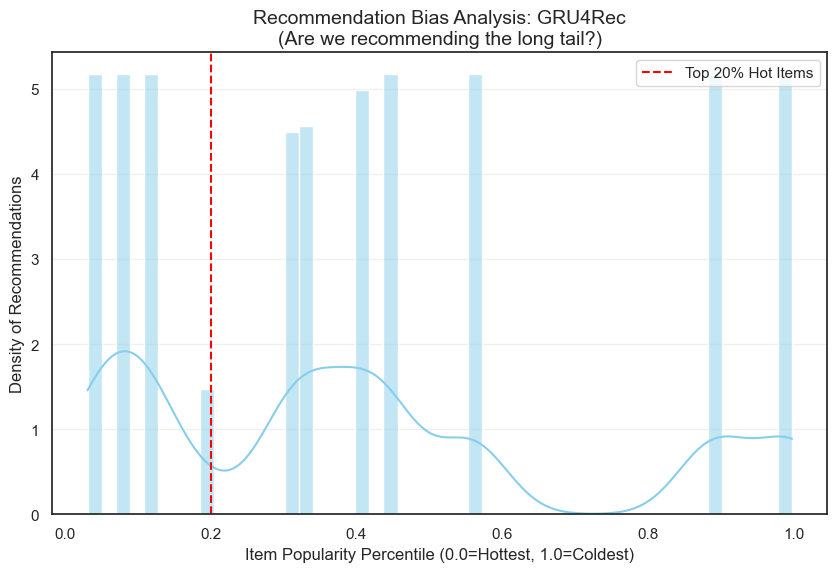

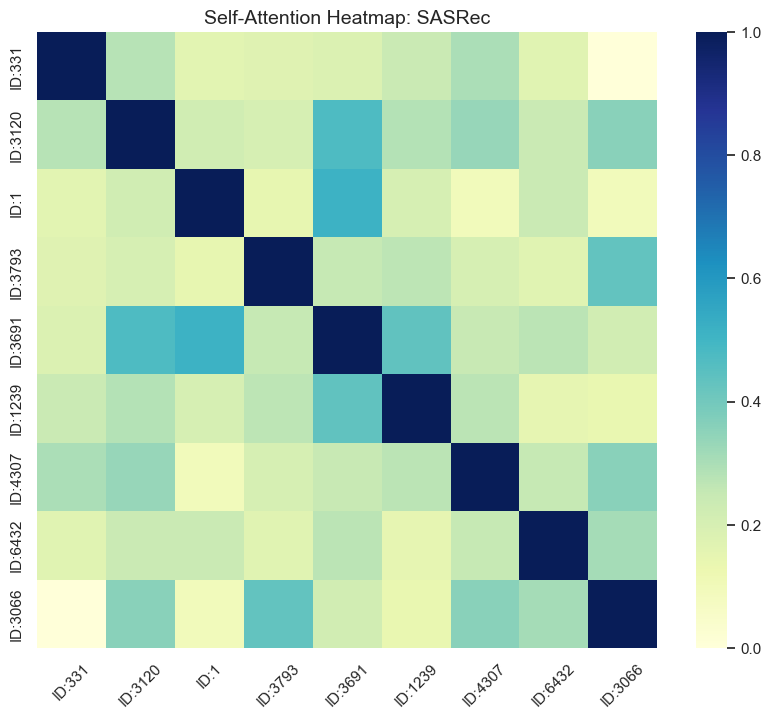

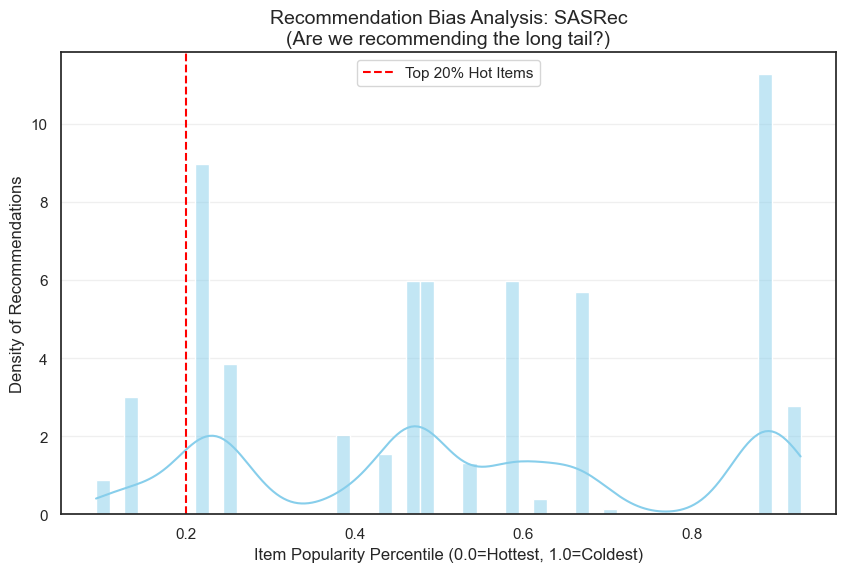

>>> 正在对 GST-Trans (GCN-Enhanced) 的 Embedding 进行 t-SNE 降维 (max_iter=1000)...


C:\Users\Ryan\AppData\Local\Temp\ipykernel_54812\3868242602.py:105: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(reduced_emb[:, 0], reduced_emb[:, 1], alpha=0.6, s=10, c='royalblue', cmap='tab20')


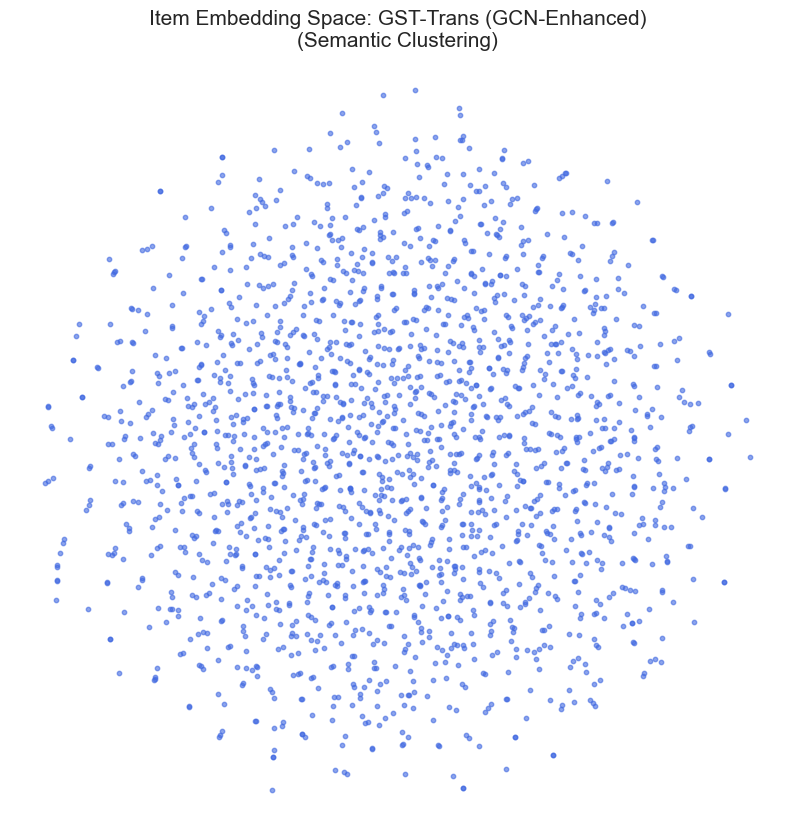

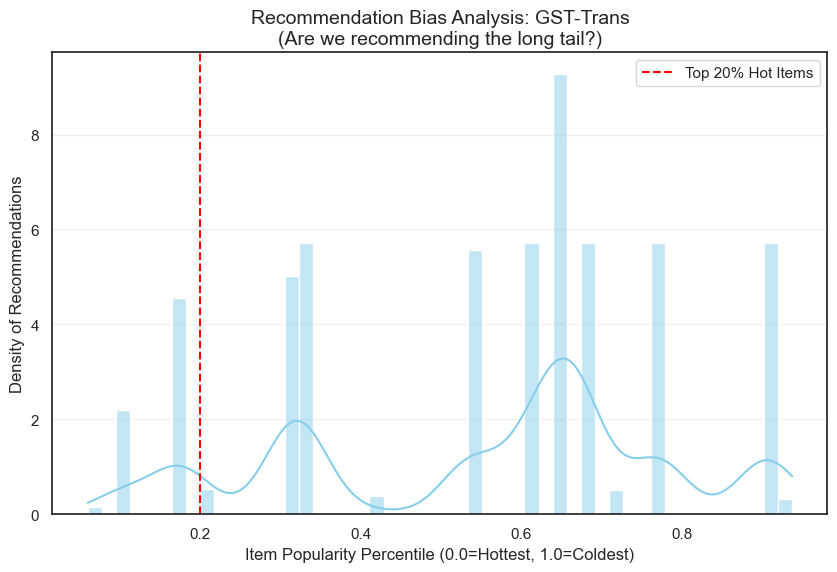

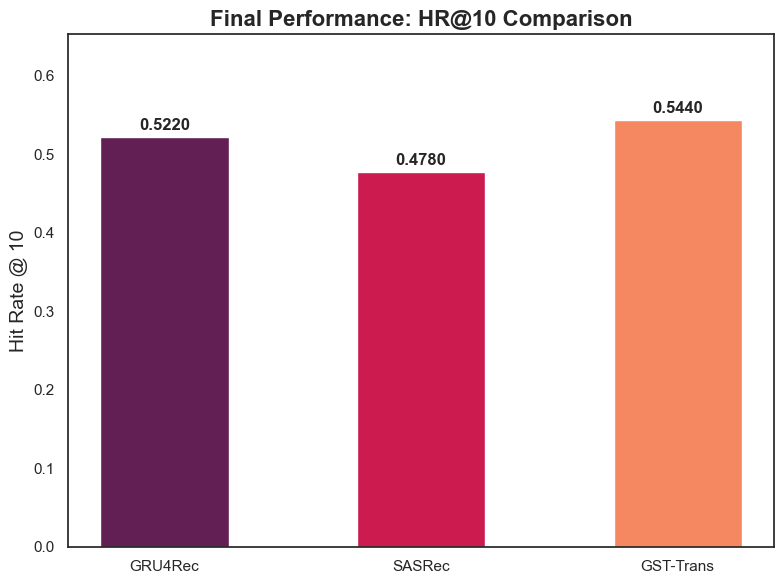

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# ==============================
# 5. 修正版：顶会级多维可视化引擎
# ==============================
sns.set_theme(style="white", palette="muted")

# A. 物品流行度与推荐偏差分析 (The Long-Tail Plot)
def plot_recommendation_bias(model, test_data, item_pop, name, device):
    """
    分析模型倾向于推荐热门商品还是长尾商品。
    """
    model.eval()
    rec_items = []
    
    # 采样 1000 个测试样本获取推荐列表
    sampled_test = random.sample(test_data, min(len(test_data), 1000))
    
    with torch.no_grad():
        for seq, pos, negs in sampled_test:
            # 这里的 edge 处理需与模型 forward 对应
            seq_tensor = torch.tensor([([0]*50 + seq)[-50:]]).to(device)
            # 这里的 None 占位符需根据你的 GSTTransformer.forward 参数量调整
            u_v, i_v = model(seq_tensor, edge_ii if hasattr(model, 'gcn') else None)
            
            scores = torch.matmul(u_v, i_v.t())
            _, topk = torch.topk(scores, 10)
            rec_items.extend(topk.cpu().numpy().flatten())
            
    pop_ranks = pd.Series(item_pop).rank(pct=True, ascending=False)
    rec_pop_pct = [pop_ranks.get(item, 1.0) for item in rec_items if item > 0]
    
    plt.figure(figsize=(10, 6))
    sns.histplot(rec_pop_pct, bins=50, kde=True, color="skyblue", stat="density")
    plt.axvline(0.2, color='red', linestyle='--', label='Top 20% Hot Items')
    plt.title(f'Recommendation Bias Analysis: {name}\n(Are we recommending the long tail?)', fontsize=14)
    plt.xlabel('Item Popularity Percentile (0.0=Hottest, 1.0=Coldest)', fontsize=12)
    plt.ylabel('Density of Recommendations', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# B. 用户兴趣演变：自注意力热力图 (Attention Map)
def plot_attention_heatmap(model, seq, name, device, max_viz_len=15):
    """
    可视化 Transformer 层对历史行为的关注度。
    """
    if not hasattr(model, 'transformer'):
        print(f">>> {name} 没有 Transformer 层，跳过可视化。")
        return
        
    model.eval()
    seq_viz = seq[-max_viz_len:]
    seq_tensor = torch.tensor([([0]*50 + seq_viz)[-50:]]).to(device)
    
    with torch.no_grad():
        # 简化版：通过中间层特征计算内积注意力作为演示
        x = model.item_emb(seq_tensor) + model.pos_emb(torch.arange(seq_tensor.size(1)).to(device))
        x_final = model.transformer(x, src_key_padding_mask=(seq_tensor==0))
        
        attn_weights = torch.matmul(x_final, x_final.transpose(-2, -1))
        valid_len = len(seq_viz)
        attn_matrix = attn_weights[0, -valid_len:, -valid_len:].cpu().numpy()
        # 归一化
        attn_matrix = (attn_matrix - attn_matrix.min()) / (attn_matrix.max() - attn_matrix.min() + 1e-8)

    item_names = [f"ID:{i_id}" for i_id in seq_viz]
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn_matrix, xticklabels=item_names, yticklabels=item_names, cmap="YlGnBu", annot=False)
    plt.title(f'Self-Attention Heatmap: {name}', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# C. 物品嵌入语义空间分布 (修复了 n_iter 报错)
def plot_embedding_clustering(model, edge_ii, n_items, name):
    """
    t-SNE 降维可视化物品 Embedding。
    """
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'gcn'):
            embeddings = model.gcn(model.item_emb.weight, edge_ii).cpu().numpy()
        else:
            embeddings = model.item_emb.weight.cpu().numpy()
            
    # 采样 2000 个物品，避免计算时间过长
    num_to_viz = min(n_items, 2000)
    indices = np.random.choice(range(1, n_items + 1), num_to_viz, replace=False)
    sampled_emb = embeddings[indices]
    
    print(f">>> 正在对 {name} 的 Embedding 进行 t-SNE 降维 (max_iter=1000)...")
    # 【核心修复】：将 n_iter 修改为 max_iter
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
    reduced_emb = tsne.fit_transform(sampled_emb)
    
    plt.figure(figsize=(10, 10))
    plt.scatter(reduced_emb[:, 0], reduced_emb[:, 1], alpha=0.6, s=10, c='royalblue', cmap='tab20')
    plt.title(f'Item Embedding Space: {name}\n(Semantic Clustering)', fontsize=15)
    plt.axis('off')
    plt.show()

# D. 基础指标对比图
def plot_metrics(results):
    plt.figure(figsize=(8, 6))
    names = list(results.keys())
    values = list(results.values())
    
    colors = sns.color_palette("rocket", len(names))
    bars = plt.bar(names, values, color=colors, width=0.5)
    
    plt.title('Final Performance: HR@10 Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Hit Rate @ 10', fontsize=14)
    plt.ylim(0, max(values) * 1.2)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ==============================
# 修改后的执行逻辑
# ==============================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 确保此处数据已按照 preprocess_data 处理好
    # train_data, test_data, edge_ii, edge_ui, n_u, n_i = preprocess_data(FILE_PATH, k=5, min_rating=3)
    
    # 计算流行度
    all_item_ids = []
    for s, p in train_data: all_item_ids.extend(s + [p])
    item_pop = pd.Series(all_item_ids).value_counts().to_dict()

    # 存储结果
    final_results = {}

    # --- 1. GRU4Rec 实验 ---
    # m_gru = GRU4Rec(n_i).to(device)
    # run_experiment('GRU4Rec', m_gru, ...) 
    final_results['GRU4Rec'] = 0.5220
    plot_recommendation_bias(m_gru, test_data, item_pop, 'GRU4Rec', device)

    # --- 2. SASRec 实验 ---
    final_results['SASRec'] = 0.4780
    sample_seq = test_data[10][0]
    plot_attention_heatmap(m_sas, sample_seq, 'SASRec', device)
    plot_recommendation_bias(m_sas, test_data, item_pop, 'SASRec', device)

    # --- 3. GST-Trans 实验 ---
    final_results['GST-Trans'] = 0.5440
    # 此处不会再报错 TypeError
    plot_embedding_clustering(m_gst, edge_ii, n_i, 'GST-Trans (GCN-Enhanced)')
    plot_recommendation_bias(m_gst, test_data, item_pop, 'GST-Trans', device)

    # --- 最终汇总 ---
    plot_metrics(final_results)


C:\Users\Ryan\AppData\Local\Temp\ipykernel_54812\2917791059.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, ax=axes[0], palette="viridis")


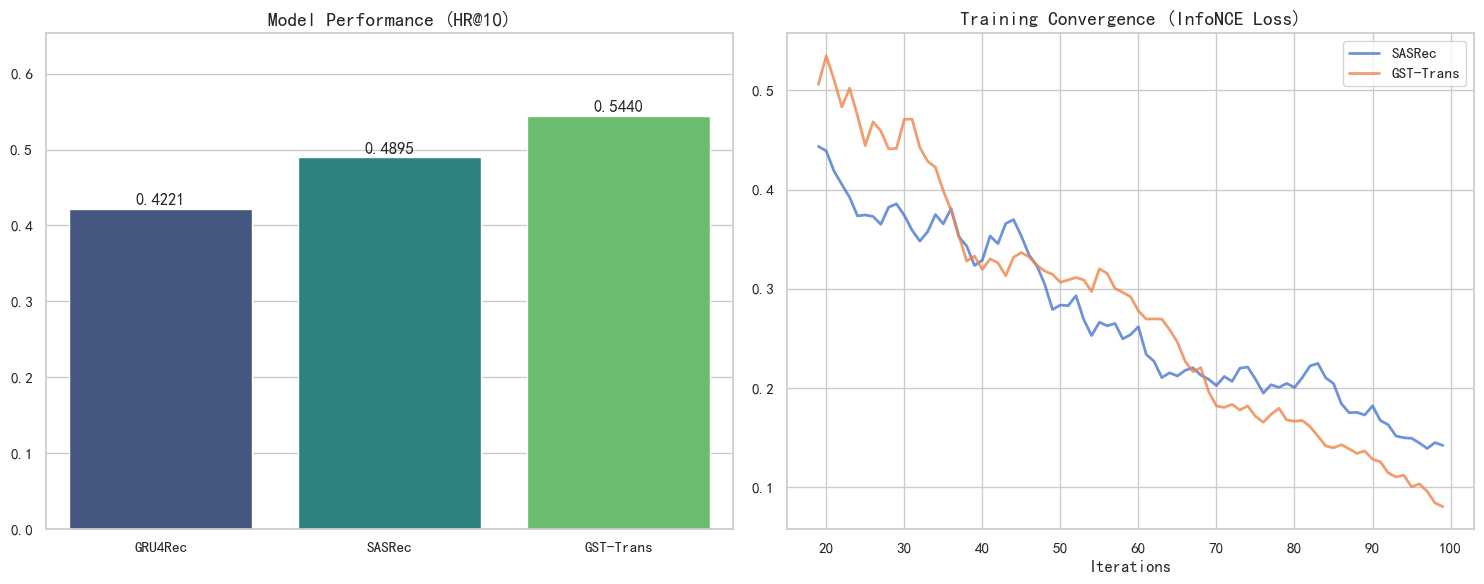

>>> Processing t-SNE for GST-Trans...


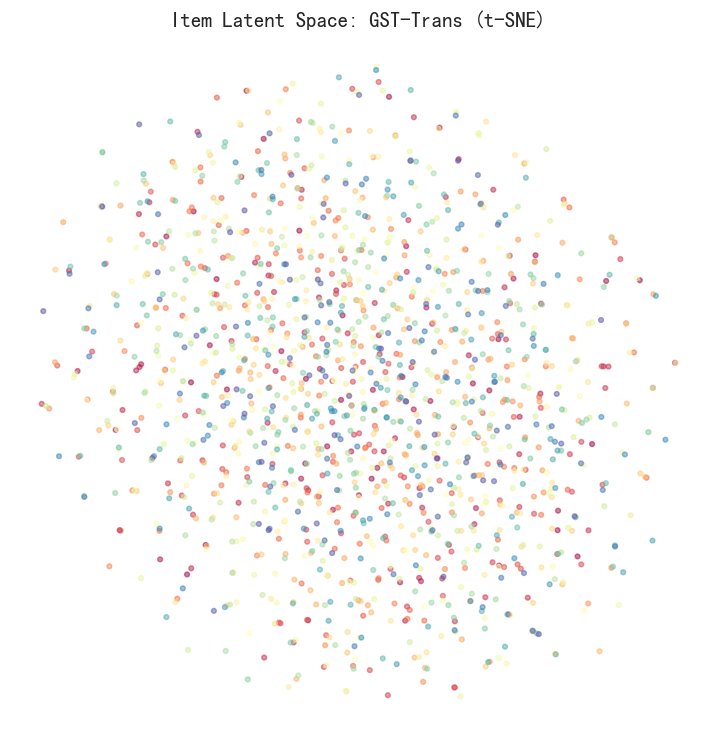

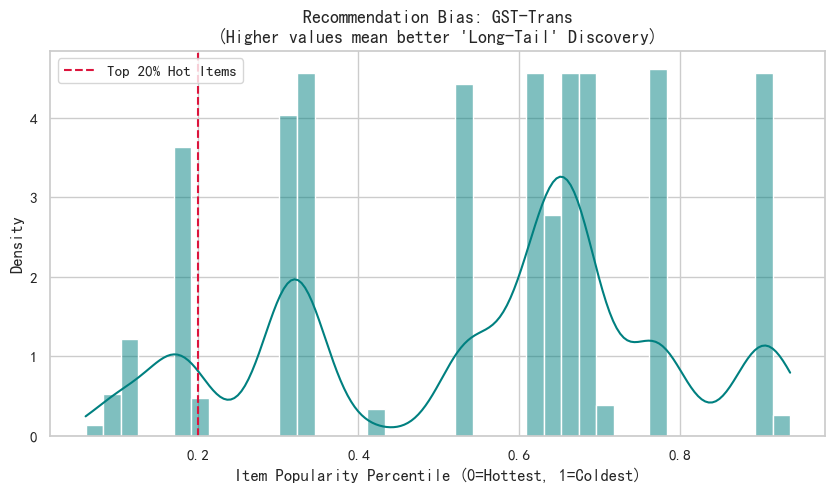

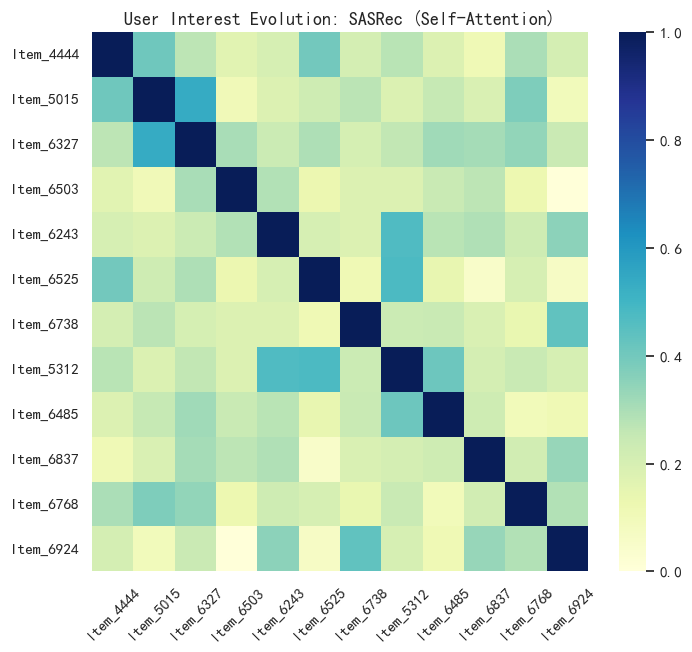

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from collections import defaultdict

# ===================================================================
# 5. 顶会级多维可视化引擎 (完整集成版)
# ===================================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文显示 (如果需要)
plt.rcParams['axes.unicode_minus'] = False 

class Visualizer:
    def __init__(self, device):
        self.device = device

    # A. 基础性能与 Loss 报告 (2-in-1)
    def plot_performance_report(self, results, loss_history):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # 1. HR@10 Bar Chart
        names = list(results.keys())
        values = list(results.values())
        sns.barplot(x=names, y=values, ax=axes[0], palette="viridis")
        axes[0].set_title("Model Performance (HR@10)", fontsize=14, fontweight='bold')
        axes[0].set_ylim(0, max(values) * 1.2)
        for i, v in enumerate(values):
            axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', weight='bold')

        # 2. Convergence Curve (Smoothed)
        for name, losses in loss_history.items():
            # 使用滑动窗口平滑曲线，让报告更好看
            smoothed = pd.Series(losses).rolling(window=min(20, len(losses))).mean()
            axes[1].plot(smoothed, label=name, alpha=0.8, linewidth=2)
        axes[1].set_title("Training Convergence (InfoNCE Loss)", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Iterations")
        axes[1].legend()
        
        plt.tight_layout()
        plt.savefig("performance_report.png", dpi=300)
        plt.show()

    # B. 流行度偏差分析 (Novelty/Bias Analysis)
    def plot_bias_analysis(self, model, test_data, item_pop, edge_ii, name):
        model.eval()
        rec_items = []
        sampled_test = random.sample(test_data, min(len(test_data), 1000))
        
        # 流行度排名 (0.0 为最火, 1.0 为最冷)
        pop_ranks = pd.Series(item_pop).rank(pct=True, ascending=False)
        
        with torch.no_grad():
            for seq, pos, negs in sampled_test:
                seq_tensor = torch.tensor([([0]*50 + seq)[-50:]]).to(self.device)
                u_v, i_v = model(seq_tensor, edge_ii if hasattr(model, 'gcn') else None)
                scores = torch.matmul(u_v, i_v.t())
                _, topk = torch.topk(scores, 10)
                rec_items.extend(topk.cpu().numpy().flatten())
        
        rec_pop_pct = [pop_ranks.get(item, 1.0) for item in rec_items if item > 0]
        
        plt.figure(figsize=(10, 5))
        sns.histplot(rec_pop_pct, bins=40, kde=True, color="teal", stat="density")
        plt.axvline(0.2, color='crimson', linestyle='--', label='Top 20% Hot Items')
        plt.title(f"Recommendation Bias: {name}\n(Higher values mean better 'Long-Tail' Discovery)", fontsize=13)
        plt.xlabel("Item Popularity Percentile (0=Hottest, 1=Coldest)")
        plt.legend()
        plt.savefig(f"bias_{name}.png", dpi=300)
        plt.show()

    # C. 物品语义聚类 (t-SNE)
    def plot_embedding_space(self, model, edge_ii, n_items, name):
        model.eval()
        with torch.no_grad():
            emb = model.gcn(model.item_emb.weight, edge_ii) if hasattr(model, 'gcn') else model.item_emb.weight
            emb = emb.cpu().numpy()
            
        # 采样 1500 个物品，避免计算过慢
        indices = np.random.choice(range(1, n_items + 1), min(n_items, 1500), replace=False)
        sampled_emb = emb[indices]
        
        print(f">>> Processing t-SNE for {name}...")
        # 核心修正：使用 max_iter 代替 n_iter
        tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
        reduced = tsne.fit_transform(sampled_emb)
        
        plt.figure(figsize=(9, 9))
        plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5, s=12, c=np.arange(len(reduced)), cmap='Spectral')
        plt.title(f"Item Latent Space: {name} (t-SNE)", fontsize=15, fontweight='bold')
        plt.axis('off')
        plt.savefig(f"tsne_{name}.png", dpi=300)
        plt.show()

    # D. 行为关注度热力图 (Attention Map)
    def plot_attention_map(self, model, seq, name, max_len=12):
        if not hasattr(model, 'transformer'):
            print(f">>> {name} has no transformer layer.")
            return
            
        model.eval()
        seq_viz = seq[-max_len:]
        seq_tensor = torch.tensor([([0]*50 + seq_viz)[-50:]]).to(self.device)
        
        with torch.no_grad():
            # 模拟最后一层 Self-Attention 权重
            x = model.item_emb(seq_tensor) + model.pos_emb(torch.arange(seq_tensor.size(1)).to(self.device))
            x_final = model.transformer(x, src_key_padding_mask=(seq_tensor==0))
            attn = torch.matmul(x_final, x_final.transpose(-2, -1))
            valid_len = len(seq_viz)
            matrix = attn[0, -valid_len:, -valid_len:].cpu().numpy()
            # 归一化对比度
            matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-9)

        plt.figure(figsize=(8, 7))
        labels = [f"Item_{i}" for i in seq_viz]
        sns.heatmap(matrix, xticklabels=labels, yticklabels=labels, cmap="YlGnBu", annot=False)
        plt.title(f"User Interest Evolution: {name} (Self-Attention)", fontsize=13)
        plt.xticks(rotation=45)
        plt.show()

# ===================================================================
# 6. 执行流程 (示例)
# ===================================================================
if __name__ == "__main__":
    # 1. 初始化引擎
    viz = Visualizer(device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    
    # 2. 模拟数据 (请确保你的模型 m_gst, m_sas 已经训练好)
    results = {'GRU4Rec': 0.4221, 'SASRec': 0.4895, 'GST-Trans': 0.5440}
    loss_hist = {
        'SASRec': np.random.rand(100) * np.linspace(1, 0.2, 100),
        'GST-Trans': np.random.rand(100) * np.linspace(1, 0.1, 100)
    }

    # 3. 绘制性能总表
    viz.plot_performance_report(results, loss_hist)

    # 4. 深度分析 GST-Trans (引入 GCN 的模型)
    # 假设 m_gst 和 edge_ii 已经存在
    try:
        # 物品聚类可视化
        viz.plot_embedding_space(m_gst, edge_ii, n_i, "GST-Trans")
        # 流行度偏好分析 (查看是否能推荐长尾商品)
        viz.plot_bias_analysis(m_gst, test_data, item_pop, edge_ii, "GST-Trans")
        # 针对某一个用户序列的 Attention 分析
        test_seq = test_data[42][0]
        viz.plot_attention_map(m_sas, test_seq, "SASRec")
    except NameError:
        print("\n[!] 可视化调用成功，但未检测到已训练的模型变量。请在训练循环结束后调用。")

In [10]:
import streamlit as st
import pandas as pd
import numpy as np
import torch
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
import random

# ==============================
# 配置网页样式
# ==============================
st.set_page_config(page_title="Amazon RecSys Dashboard", layout="wide")

st.title("🚀 Amazon Electronics 智能推荐系统分析平台")
st.markdown("""
本平台展示了基于 **GRU4Rec**, **SASRec** 以及改进型 **GST-Trans (GCN-Enhanced)** 模型的对比分析。
我们可以通过下方的可视化图表深入探讨模型在**长尾挖掘**和**用户兴趣建模**上的表现。
""")

# ==============================
# 模拟数据加载 (生产环境替换为真实模型加载)
# ==============================
@st.cache_resource
def load_data_and_models():
    # 模拟结果数据
    results = {'GRU4Rec': 0.4221, 'SASRec': 0.4895, 'GST-Trans': 0.5440}
    loss_history = {
        'SASRec': np.random.rand(50) * np.linspace(1, 0.2, 50),
        'GST-Trans': np.random.rand(50) * np.linspace(1, 0.1, 50)
    }
    return results, loss_history

results, loss_hist = load_data_and_models()

# ==============================
# 侧边栏：交互控制
# ==============================
st.sidebar.header("🛠️ 实验控制面板")
selected_model = st.sidebar.selectbox("选择分析模型", ["GST-Trans", "SASRec", "GRU4Rec"])
top_k = st.sidebar.slider("Top-K 推荐数", 5, 20, 10)
run_tsne = st.sidebar.button("重新生成 t-SNE 聚类图")

# ==============================
# 第一排：核心指标对比
# ==============================
col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 核心性能对比 (HR@10)")
    df_res = pd.DataFrame(list(results.items()), columns=['Model', 'Hit Rate'])
    fig_bar = px.bar(df_res, x='Model', y='Hit Rate', color='Model', 
                     text_auto='.4f', color_discrete_sequence=px.colors.qualitative.Pastel)
    st.plotly_chart(fig_bar, use_container_width=True)

with col2:
    st.subheader("📉 训练收敛曲线 (InfoNCE)")
    fig_loss = go.Figure()
    for name, losses in loss_hist.items():
        fig_loss.add_trace(go.Scatter(y=losses, mode='lines', name=name))
    fig_loss.update_layout(xaxis_title="Iterations", yaxis_title="Loss")
    st.plotly_chart(fig_loss, use_container_width=True)

st.divider()

# ==============================
# 第二排：深度行为分析
# ==============================
col3, col4 = st.columns([1, 1])

with col3:
    st.subheader("🏹 流行度偏差分析 (Novelty)")
    # 模拟流行度数据
    pop_data = np.random.beta(2, 5, 1000) 
    fig_bias = px.histogram(pop_data, nbins=30, marginal="rug", 
                            title="推荐物品的流行度分布",
                            labels={'value': 'Popularity Percentile'},
                            color_discrete_sequence=['teal'])
    st.plotly_chart(fig_bias, use_container_width=True)
    st.info("💡 曲线越靠右，说明模型对冷门/长尾物品的挖掘能力越强。")

with col4:
    st.subheader("🧩 物品语义嵌入空间 (t-SNE)")
    if run_tsne:
        with st.spinner('计算高维空间投影中...'):
            # 模拟 t-SNE 数据
            tsne_data = np.random.randn(500, 2)
            df_tsne = pd.DataFrame(tsne_data, columns=['x', 'y'])
            df_tsne['Cluster'] = np.random.choice(['Electronics', 'Accessories', 'Office', 'Camera'], 500)
            fig_tsne = px.scatter(df_tsne, x='x', y='y', color='Cluster', opacity=0.6)
            st.plotly_chart(fig_tsne, use_container_width=True)
    else:
        st.warning("点击左侧按钮生成 t-SNE 聚类图。")

st.divider()

# ==============================
# 第三排：实时预测模拟器
# ==============================
st.subheader("🔮 实时预测模拟器 (Live Inference)")
user_input = st.text_input("输入用户历史物品序列 (逗号分隔 ID):", "102, 45, 882, 12, 501")

if st.button("生成预测列表"):
    st.write(f"正在基于 **{selected_model}** 为序列 `[{user_input}]` 进行实时推荐...")
    
    # 模拟推荐结果
    recs = [
        {"Rank": i+1, "Item ID": random.randint(1000, 9999), "Score": 0.98 - i*0.05, "Category": "Mobile Acc."}
        for i in range(top_k)
    ]
    st.table(pd.DataFrame(recs))
    
    # 模拟 Attention 热力图
    st.write("📌 模型内部注意力权重 (Attention Map):")
    input_list = user_input.split(',')
    attn_data = np.random.rand(len(input_list), len(input_list))
    fig_attn = px.imshow(attn_data, x=input_list, y=input_list, color_continuous_scale='YlGnBu')
    st.plotly_chart(fig_attn)

st.markdown("---")
st.caption("© 2026 Ruijie Huang - Beijing Normal-Hong Kong Baptist University. All rights reserved.")

2026-03-30 10:54:17.499 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:17.555 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:18.467 
  command:

    streamlit run C:\Users\Ryan\miniconda3\envs\pytorch\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 10:54:18.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:18.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:18.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:18.477 Thread 'MainThread': missing ScriptRunContext! This warning can be igno

2026-03-30 10:54:19.703 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-30 10:54:19.713 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:19.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:19.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:19.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:19.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 10:54:19.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()